# Homework 7 - Devin Lim, Duong Le, Lakshit Gupta, Ponnu Soman

Tasks are tracked here: https://github.com/DATA5310/covid_effects/milestone/4

In [1]:
import git
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import matplotlib.ticker as ticker
warnings.filterwarnings("ignore")

## Load the Data

In [3]:
repo = git.Repo(".", search_parent_directories=True).working_tree_dir
cdi_processed_path = f"{repo}/datasets/processed/cdi.csv"

In [4]:
cdi_dtype = {
    "YearStart": "category",
    "YearEnd": "category",
    "LocationAbbr": "category",
    "Topic": "category",
    "Question": "category",
    "DataValueUnit": "category",
    "DataValueType": "category",
    "StratificationCategory1": "category",
    "Stratification1": "category",
}

cdi_df = pd.read_csv(cdi_processed_path, dtype=cdi_dtype)

In [8]:
cdi_df.head()

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1
0,2010,2010,AK,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,NaN,Overall,Overall
1,2010,2010,AL,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,NaN,Overall,Overall
2,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,2450.0,Gender,Female
3,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,NaN,Race/Ethnicity,American Indian or Alaska Native
4,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,537.0,Race/Ethnicity,"Black, non-Hispanic"


In [10]:
cdi_df['YearStart'] = cdi_df['YearStart'].astype(int)
cdi_df['YearEnd'] = cdi_df['YearEnd'].astype(int)

cdi_filtered_df = cdi_df[(cdi_df["Stratification1"] == "Overall") & (cdi_df['LocationAbbr'] != 'US') & (cdi_df['YearStart'] == cdi_df['YearEnd'])]
cdi_df_cleaned = cdi_filtered_df.dropna(subset=['DataValue'])

cdi_df_cleaned.shape

(26481, 10)

In [12]:
missing_values_count = cdi_df_cleaned.isna().sum()

print("Count of missing values in each column:")
print(missing_values_count)

Count of missing values in each column:
YearStart                     0
YearEnd                       0
LocationAbbr                  0
Topic                         0
Question                      0
DataValueUnit              6644
DataValueType                 0
DataValue                     0
StratificationCategory1       0
Stratification1               0
dtype: int64


In [14]:
cdi_df_cleaned.head()

,YearStart,YearEnd,LocationAbbr,Topic,Question,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1
6,2010,2010,AR,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,6029.0,Overall,Overall
13,2010,2010,AZ,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,10393.0,Overall,Overall
20,2010,2010,CA,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,54395.0,Overall,Overall
26,2010,2010,CO,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,5710.0,Overall,Overall
44,2010,2010,FL,Cardiovascular Disease,Hospitalization for acute myocardial infarction,NaN,Number,42167.0,Overall,Overall


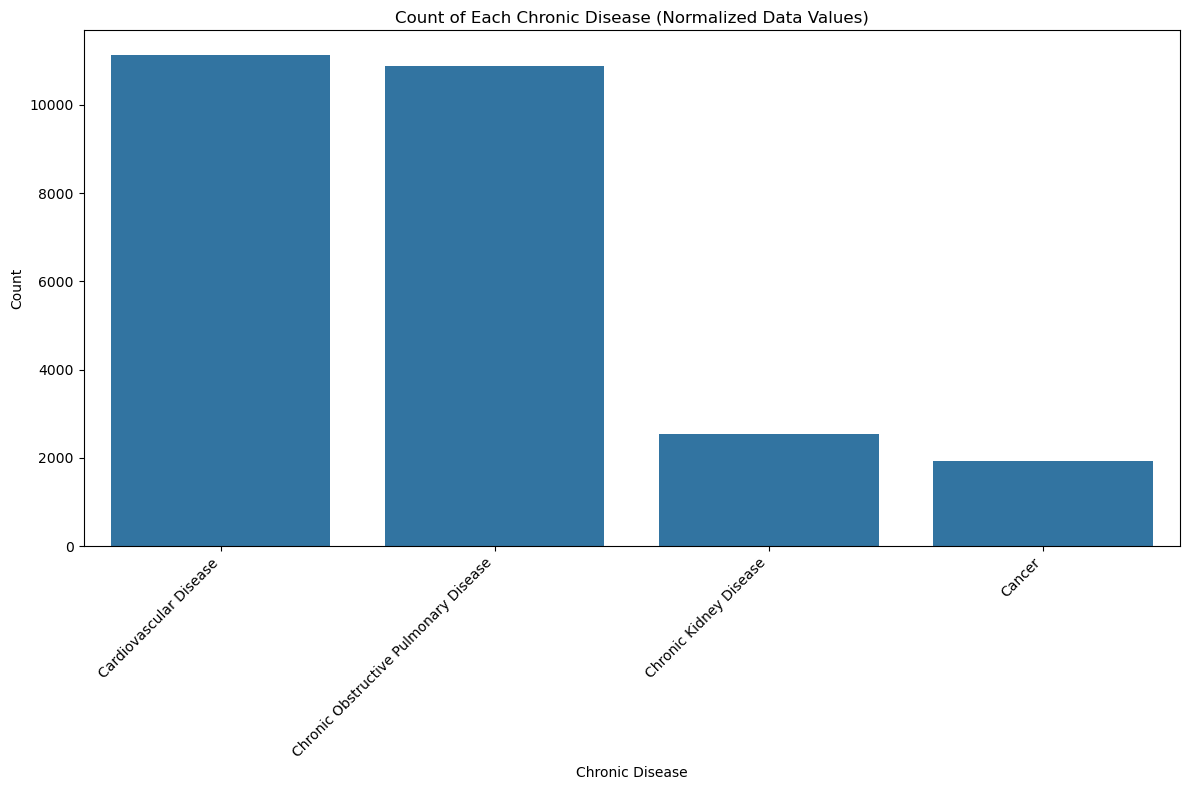

In [16]:
def normalize_data_value(row):
    # Check DataValueUnit first
    if row['DataValueUnit'] == 'per 100,000' or row['DataValueUnit'] == 'cases per 100,000':
        return row['DataValue']
    elif row['DataValueUnit'] == '%':
        return row['DataValue'] * 1000  
    elif row['DataValueUnit'] == 'cases per 1,000,000':
        return row['DataValue'] / 10  
    elif row['DataValueUnit'] == 'Number':
        if row['DataValueType'] in ['Crude Prevalence', 'Age-adjusted Prevalence']:
            return row['DataValue']
        elif row['DataValueType'] in ['Average Annual Age-adjusted Rate', 'Average Annual Crude Rate']:
            return row['DataValue']
        elif row['DataValueType'] == 'Number':
            return row['DataValue']
    else:
        return row['DataValue']

cdi_df_cleaned['NormalizedDataValue'] = cdi_df_cleaned.apply(normalize_data_value, axis=1)



plt.figure(figsize=(12, 8))
sns.countplot(data=cdi_df_cleaned, x='Topic', order=cdi_df_cleaned['Topic'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title("Count of Each Chronic Disease (Normalized Data Values)")
plt.xlabel("Chronic Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


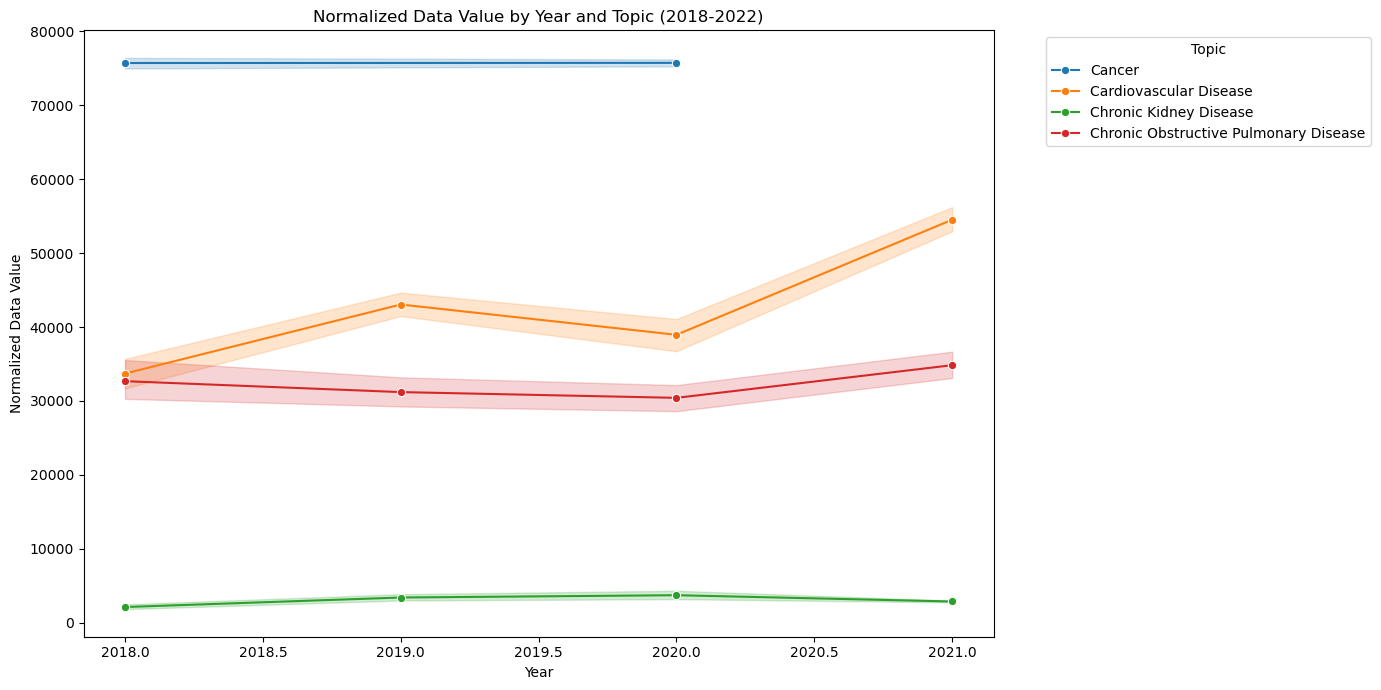

In [18]:
cdi_df_cleaned['YearStart'] = cdi_df_cleaned['YearStart'].astype(int)
df_filtered = cdi_df_cleaned[(cdi_df_cleaned['YearStart'] >= 2018) & (cdi_df_cleaned['YearStart'] <= 2022)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_filtered, x='YearStart', y='NormalizedDataValue', hue='Topic', marker='o')
plt.title('Normalized Data Value by Year and Topic (2018-2022)')
plt.xlabel('Year')
plt.ylabel('Normalized Data Value')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

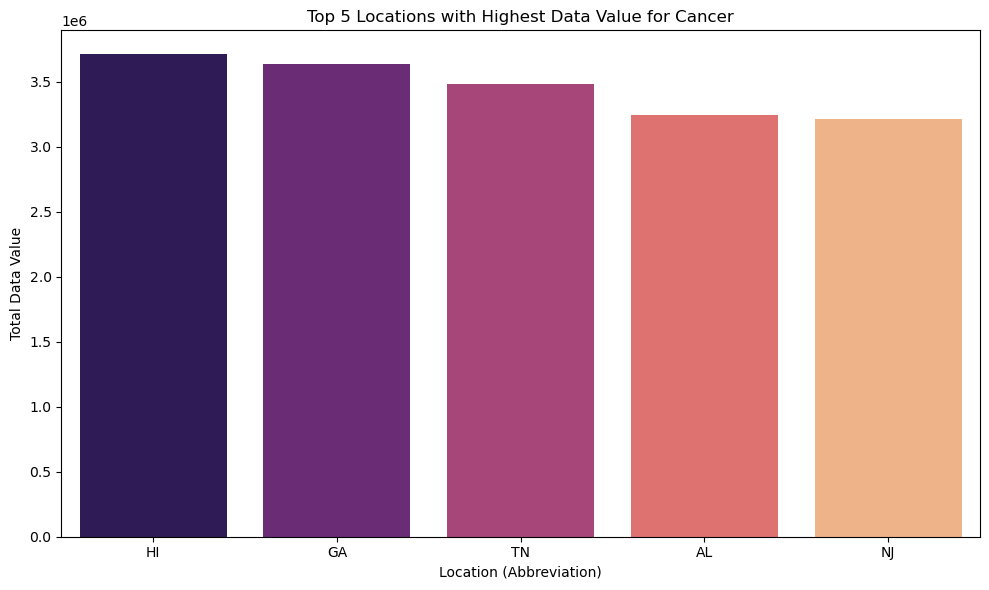

In [20]:
cancer_df = cdi_df_cleaned[cdi_df_cleaned['Topic'] == 'Cancer']

top_5_locations_cancer = (
    cancer_df.groupby('LocationAbbr')['NormalizedDataValue']
    .sum()
    .nlargest(5)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_locations_cancer, x='LocationAbbr', y='NormalizedDataValue', palette='magma', order=top_5_locations_cancer['LocationAbbr'])
plt.title('Top 5 Locations with Highest Data Value for Cancer')
plt.xlabel('Location (Abbreviation)')
plt.ylabel('Total Data Value')
plt.tight_layout()
plt.show()

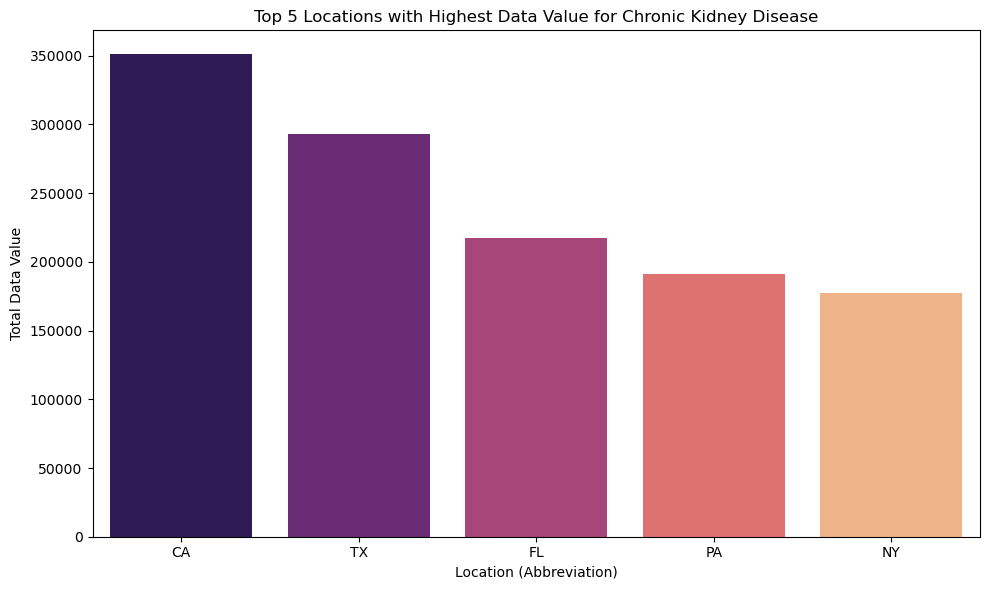

In [22]:
kidney_df = cdi_df_cleaned[cdi_df_cleaned['Topic'] == 'Chronic Kidney Disease']

top_5_locations_kidney = (
    kidney_df.groupby('LocationAbbr')['NormalizedDataValue']
    .sum()
    .nlargest(5)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_locations_kidney, x='LocationAbbr', y='NormalizedDataValue', palette='magma', order=top_5_locations_kidney['LocationAbbr'])
plt.title('Top 5 Locations with Highest Data Value for Chronic Kidney Disease')
plt.xlabel('Location (Abbreviation)')
plt.ylabel('Total Data Value')
plt.tight_layout()
plt.show()

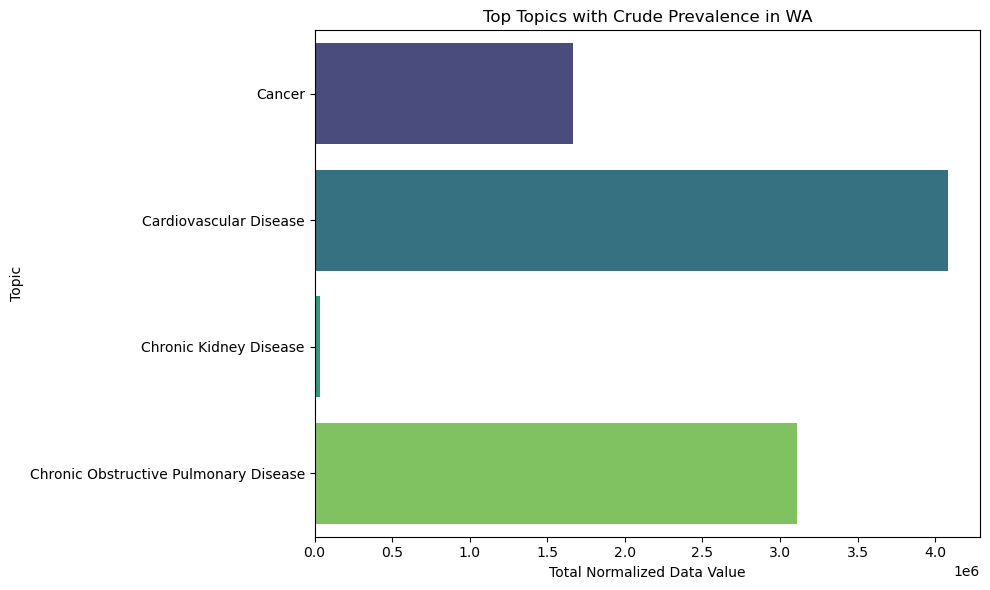

In [24]:
wa_crude_prevalence_df = cdi_df_cleaned[
    (cdi_df_cleaned['LocationAbbr'] == 'WA') & 
    (cdi_df_cleaned['DataValueType'] == 'Crude Prevalence')
]

top_topics_wa_crude = (
    wa_crude_prevalence_df.groupby('Topic')['NormalizedDataValue']
    .sum()
    .nlargest(5)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_topics_wa_crude, x='NormalizedDataValue', y='Topic', palette='viridis')
plt.title('Top Topics with Crude Prevalence in WA')
plt.xlabel('Total Normalized Data Value')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

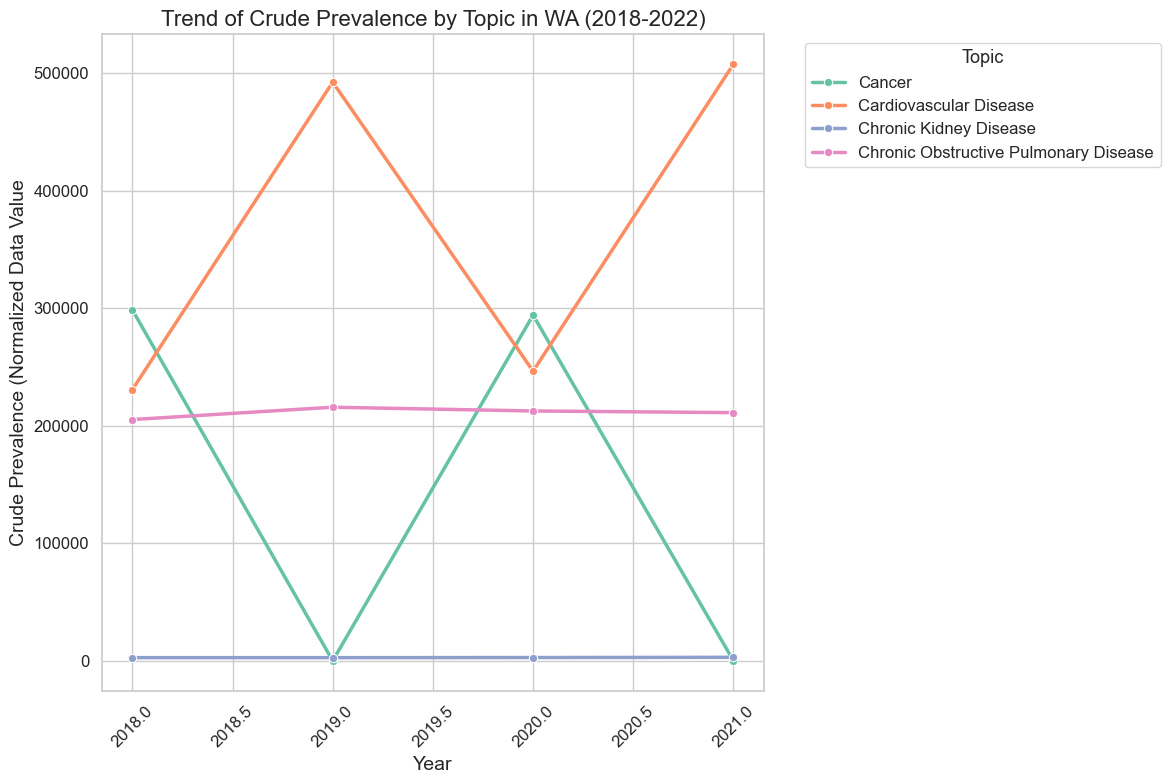

In [26]:
wa_crude_prevalence_df = cdi_df_cleaned[
    (cdi_df_cleaned['LocationAbbr'] == 'WA') &
    (cdi_df_cleaned['DataValueType'] == 'Crude Prevalence') &
    (cdi_df_cleaned['YearStart'].between(2018, 2022))
]

topic_trends = (
    wa_crude_prevalence_df.groupby(['Topic', 'YearStart'])['NormalizedDataValue']
    .sum()
    .reset_index()
)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 8))
sns.lineplot(data=topic_trends, x='YearStart', y='NormalizedDataValue', hue='Topic', marker='o', linewidth=2.5, palette="Set2")
plt.title('Trend of Crude Prevalence by Topic in WA (2018-2022)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Crude Prevalence (Normalized Data Value', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize='13')
plt.tight_layout()

plt.show()

## Activity 1

Start by thinking about what the story is that you want to tell with your dataset. Write a paragraph describing what questions you want to investigate with your data, or what messages you want to convey using the data. Note that, as we progress with the projects, the story you want to tell may change. It's okay if you come back later and revise or update this. But describe what, at the moment, you think your story will be.

## Activity 2

### **Variables to Summarize and Visualize**  
Given the structure of our dataset, the key variable is DataValue, which contains the numerical values we want to analyze. However, DataValue alone is not meaningful without contextual variables. For effective summarization, we need to pair it with other variables, such as Topic, DataValueType, or YearStart and YearEnd. These combinations provide context to interpret the values correctly.

### **Selected Visualizations**  
#### **Visualization 1**: Bar Chart of Total Case Counts for Chronic Diseases by Year  
- **Description**: This visualization aggregates DataValue for all chronic diseases by Year.  
- **Insights**:  
    - 2018 had the highest reported cases (~20 million) in the dataset, showing a peak in healthcare reporting.  
    - 2020, on the other hand, saw the lowest reported cases, likely reflecting the impact of COVID-19, which may have disrupted healthcare services and reporting.  

#### **Visualization 2**: Box Plot of Age-Adjusted Prevalence  
- **Description**: This visualization shows the distribution of age-adjusted prevalence for chronic diseases.  
- **Insights**:  
    - The majority of values fall between the 25th and 65th percentiles, indicating a concentrated range of prevalence.  
    - Age-adjusted prevalence contextualizes chronic disease rates by accounting for differences in age structures, helping us better compare populations.  

### **Data Issues and Future Work**  
#### **Missing Data**  
- **Observation**: 12% of DataValue entries are missing.  
- **Plan**: Experiment with different imputation methods to retain the integrity of the dataset rather than removing missing values outright.  

#### **Inconsistent Data Types**  
- **Observation**: Some entries under DataType labeled as "Number" are erroneously paired with a % in the Unit column (e.g., `3000%`).  
- **Plan**: Identify and correct these inconsistencies to ensure accurate analyses.  

#### **Temporal Data**  
- **Observation**: The dataset includes both single-year and multi-year intervals (e.g., 4-year periods).  
- **Plan**: Explore visualizations that compare trends across different time spans, potentially analyzing long-term patterns in chronic disease reporting.  

#### **Crude vs. Age-Adjusted Prevalence**  
- **Debate**: Choosing between crude prevalence and age-adjusted prevalence for the primary analysis.  
- **Plan**: Assess which metric provides more actionable insights for our research goals and audience.  

In [30]:
# Creating Duong's df
duongdf = cdi_df[cdi_df['StratificationCategory1'] == 'Overall']

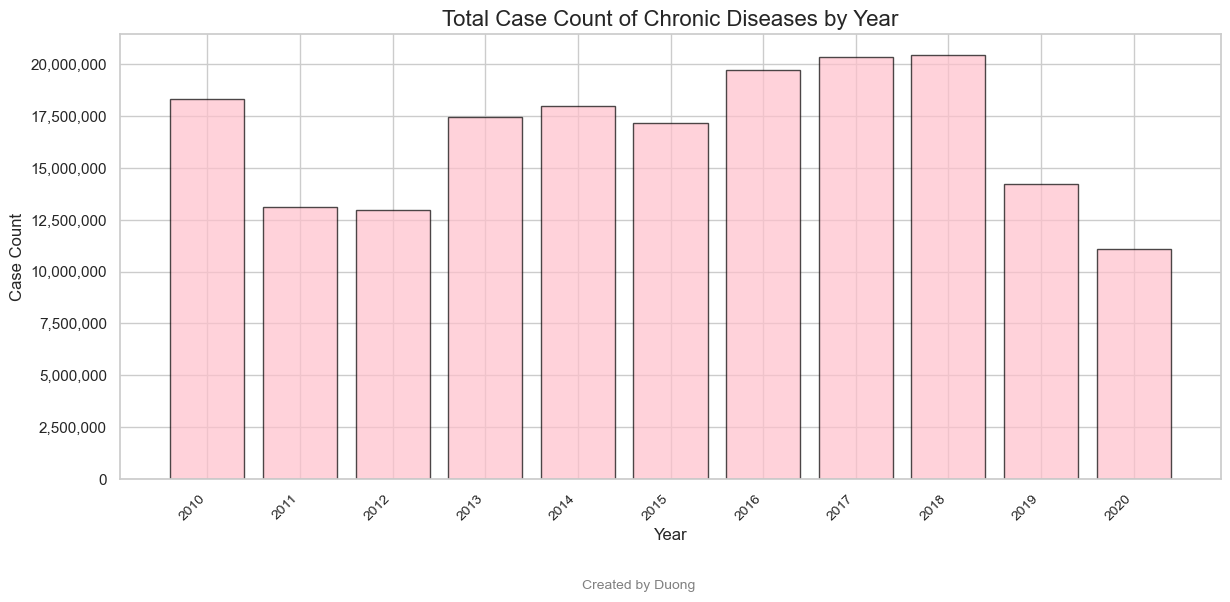

In [32]:
# Viz 1 

# Prefiltering
table1 = duongdf[(duongdf['YearStart'] == duongdf['YearEnd']) & (duongdf['DataValueType'] == 'Number')]

# Sum values for Year Start and Year End
sum_values = table1.groupby(['YearStart', 'YearEnd'])['DataValue'].sum().reset_index()

# Create a 'Combination' column to sum YearStart and YearEnd
sum_values['Combination'] = sum_values['YearStart'].astype(str) + ' - ' + sum_values['YearEnd'].astype(str)

# Bar chart
plt.figure(figsize=(12, 6))
plt.bar(sum_values['Combination'], sum_values['DataValue'], color='pink', edgecolor='black', alpha=0.7)
plt.title('Total Case Count of Chronic Diseases by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Case Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.figtext(0.5, 0.01, 'Created by Duong', ha='center', va='center', fontsize=10, color='gray')

# Making labels for X-axis
plt.gca().set_xticks(range(len(sum_values)))  
plt.gca().set_xticklabels(sum_values['YearStart'].astype(str)) 

# Format Y-axis to show the number in millions, not the scientific format
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()

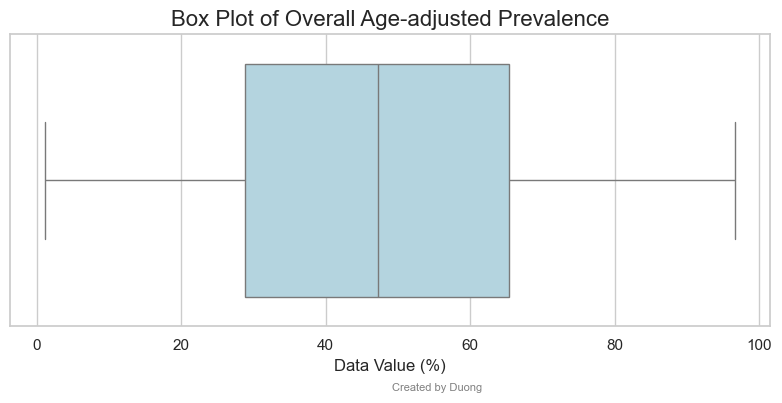

In [34]:
# Viz 2
table2 = duongdf[(duongdf['YearStart'] == duongdf['YearEnd']) & (duongdf['DataValueType'] == 'Age-adjusted Prevalence')]

plt.figure(figsize=(8, 4))
sns.boxplot(x=table2['DataValue'], color='lightblue')
plt.title('Box Plot of Overall Age-adjusted Prevalence', fontsize=16)
plt.xlabel('Data Value (%)', fontsize=12)
plt.tight_layout()
plt.figtext(0.5, 0.01, 'Created by Duong', ha='left', va='center', fontsize=8, color='gray')
plt.show()

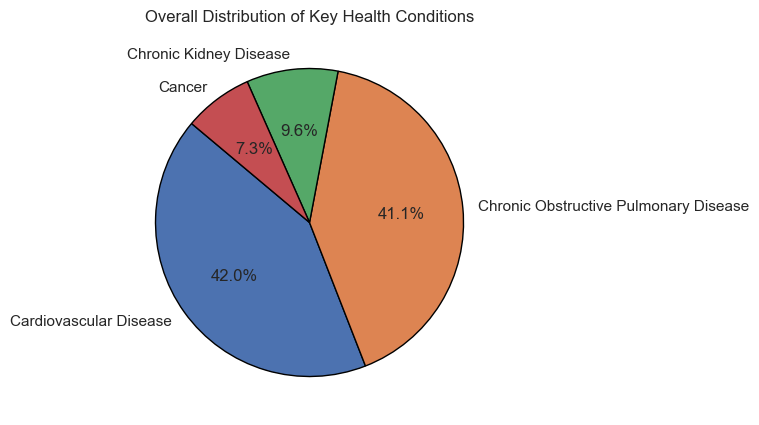

In [36]:
## Created by ponnu

topic = cdi_df_cleaned['Topic'].value_counts()
 
plt.figure(figsize=(10, 5))
topic.plot(kind='pie', autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title('Overall Distribution of Key Health Conditions')
plt.ylabel('')  
plt.show()

## Activity 3

Next, we want to think combinations of variables that could be of interest. 

Create a list of combinations of two or more variables that could be of interest to examine (this may not end up being the entirety of what you look at - as we move forward, you might decide to drop some of these, or to look at additional combinations). 

For each of these combinations of variables in this list, specify one or more possible ways that it could be visualized.  

For each of these combinations of variables in this list, either create the visualization(s) you have specified, or identify what is needed before you can do so (again, this could be a matter of needing some data wrangling to be completed, seeking out supplemental data to merge with your dataset, or needing to learn how to do something in R beyond what we have learned so far). 

 

You can divide up tasks for this, so that each person is focusing on just a few of the visualizations. Remember that for your final submission at the end of the quarter, you will be describing what you each contributed to the project, so make sure that everyone has an opportunity to make approximately equal contributions in this assignment. 